# Cuadernillo de Clasificación Multiclase: Parte 1
## Análisis del Dataset Forest Covertype

### 1. Introducción y Descripción del Dataset
El dataset **Forest Covertype** se utiliza para predecir el tipo de cubierta forestal (especie de árbol dominante) en parcelas de 30x30 metros en el Bosque Nacional Roosevelt, Colorado. A diferencia de otros problemas, este se basa puramente en variables cartográficas.

**Características principales:**
*   **Instancias:** 581,012 registros.
*   **Atributos (Features):** 54 variables independientes.
    *   10 variables continuas (elevación, pendiente, distancia a hidrología, etc.).
    *   44 variables binarias (codificadas en One-Hot) que representan áreas silvestres y tipos de suelo.
*   **Objetivo (Target):** 7 clases de cubiertas forestales (ej. Pino, Abeto, etc.).

In [17]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")

# Cargar el dataset
print("Descargando/Cargando el dataset fetch_covtype...")
covtype = fetch_covtype()
print("Dataset cargado exitosamente.")

Descargando/Cargando el dataset fetch_covtype...
Dataset cargado exitosamente.


### 2. Preprocesamiento con Pandas y Balanceo de Clases

Una inspección inicial revela que el dataset está **fuertemente desbalanceado**. Por ejemplo, las clases 1 y 2 representan la gran mayoría de los datos, mientras que la clase 4 tiene una presencia mínima.

**Estrategia:**
1.  Convertir los datos crudos de `sklearn` a un `DataFrame` de Pandas para facilitar la manipulación.
2.  Ajustar las etiquetas del objetivo (restar 1) para obtener un rango de [0, 6].
3.  Aplicar **Submuestreo (Undersampling)**: Reduciremos todas las clases al tamaño de la clase minoritaria para asegurar que el modelo no se sesgue hacia las clases más frecuentes.

In [18]:
# Crear un DataFrame de Pandas
df = pd.DataFrame(covtype.data, columns=covtype.feature_names)
# Las clases originales van del 1 al 7. Las restamos 1 para que vayan de 0 a 6 (mejor para cálculos)
df['Target'] = covtype.target - 1

print("Distribución original de clases:")
print(df['Target'].value_counts().sort_index())

# Balanceo del dataset (Undersampling)
# Buscamos el tamaño de la clase minoritaria
min_class_size = df['Target'].value_counts().min()
print(f"\nLa clase con menos ejemplos tiene {min_class_size} instancias.")
print("Reduciendo todas las clases a este número para balancear el dataset...")

# Agrupar por clase y tomar una muestra aleatoria igual al tamaño mínimo
df_balanced = df.groupby('Target').apply(lambda x: x.sample(min_class_size, random_state=42)).reset_index(drop=True)

print("\nDistribución de clases después del balanceo:")
print(df_balanced['Target'].value_counts().sort_index())

# Separar características (X) y etiquetas (y)
X = df_balanced.drop('Target', axis=1)
y = df_balanced['Target']

Distribución original de clases:
Target
0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64

La clase con menos ejemplos tiene 2747 instancias.
Reduciendo todas las clases a este número para balancear el dataset...

Distribución de clases después del balanceo:
Target
0    2747
1    2747
2    2747
3    2747
4    2747
5    2747
6    2747
Name: count, dtype: int64


/tmp/ipykernel_12205/2598342990.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('Target').apply(lambda x: x.sample(min_class_size, random_state=42)).reset_index(drop=True)


### 3. División de Datos y Escalado

Para garantizar una evaluación justa, dividiremos el dataset en conjuntos de entrenamiento (80%) y prueba (20%).

**Importancia del Escalado:**
Dado que utilizaremos algoritmos basados en el **Descenso del Gradiente**, es crítico aplicar `StandardScaler`. Esto normaliza las características para que tengan media 0 y desviación estándar 1, evitando que variables con rangos grandes (como la elevación) dominen injustamente la actualización de los pesos $\theta$.

In [19]:
# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Tamaño de prueba: {X_test.shape[0]} ejemplos")

# Escalar los datos (Media 0, Desviación estándar 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tamaño de entrenamiento: 15383 ejemplos
Tamaño de prueba: 3846 ejemplos


### 4. Regresión Logística Multiclase y Optimización de $\theta$

En un entorno multiclase, la Regresión Logística utiliza la función **Softmax** para convertir las puntuaciones del modelo en probabilidades. El modelo aprende una matriz de parámetros $\theta$ donde cada fila corresponde a los pesos de una clase específica.

**Implementación:**
Utilizaremos `SGDClassifier` con la opción `loss='log_loss'`. Esto nos permite:
1.  Realizar un entrenamiento incremental mediante `partial_fit`.
2.  Monitorear la pérdida (Cross-Entropy) y la precisión época por época, lo cual es ideal para visualizar la convergencia del modelo.

In [20]:
# Inicializar el modelo con loss='log_loss' (Regresión Logística multiclase)
# warm_start=True nos permite entrenar época por época de forma manual para guardar las métricas
clf = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.001,
                    max_iter=1, warm_start=True, random_state=42, learning_rate='optimal')

epochs = 50
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# Clases únicas para el método partial_fit
classes = np.unique(y_train)

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    # Entrenar una época
    clf.partial_fit(X_train_scaled, y_train, classes=classes)

    # Predecir probabilidades para calcular el Costo (Log Loss)
    y_train_probs = clf.predict_proba(X_train_scaled)
    y_test_probs = clf.predict_proba(X_test_scaled)

    # Guardar costos
    train_losses.append(log_loss(y_train, y_train_probs))
    test_losses.append(log_loss(y_test, y_test_probs))

    # Predecir clases para calcular la Precisión (Accuracy)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test_scaled)))

print("Entrenamiento finalizado.")

# Extraer y mostrar los parámetros Theta (Pesos del modelo)
theta = clf.coef_
sesgo = clf.intercept_
print(f"\nForma de la matriz de parámetros Theta: {theta.shape}")
print("(7 clases x 54 características. El modelo aprendió un vector Theta para cada clase)")

Iniciando entrenamiento...
Entrenamiento finalizado.

Forma de la matriz de parámetros Theta: (7, 54)
(7 clases x 54 características. El modelo aprendió un vector Theta para cada clase)


### 5. Visualización del Aprendizaje: Costo y Precisión

A continuación, generaremos curvas de aprendizaje para verificar el comportamiento del modelo.
*   **Gráfica de Costo:** Debería mostrar un descenso asintótico, indicando que el modelo está minimizando el error.
*   **Gráfica de Accuracy:** Debería mostrar un incremento estable tanto en el conjunto de entrenamiento como en el de prueba.

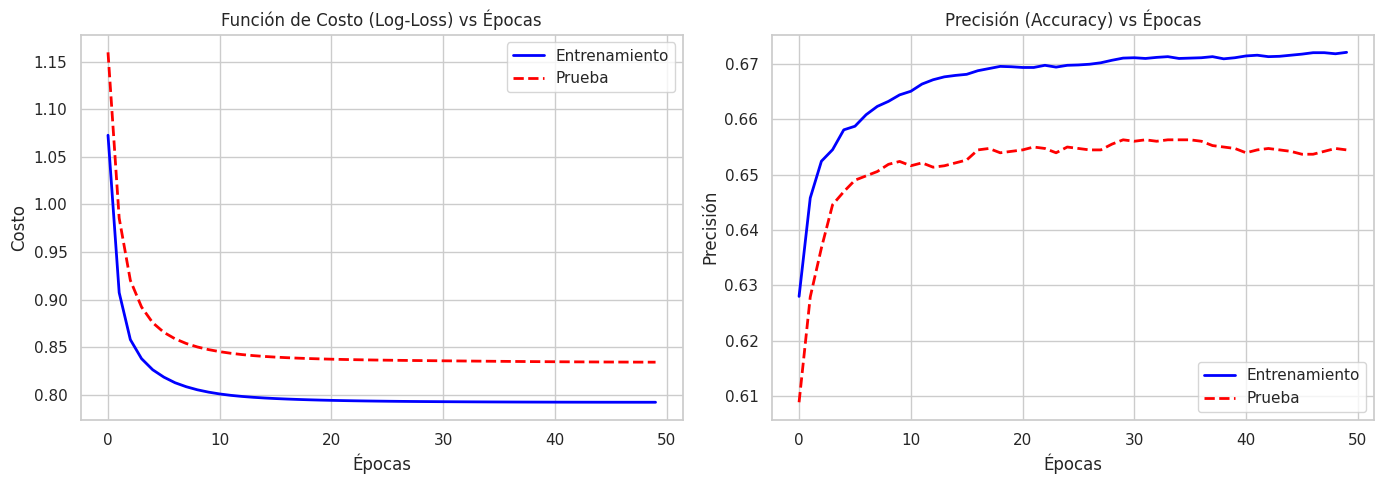

In [21]:
plt.figure(figsize=(14, 5))

# Gráfica de Costo (Loss)
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(epochs), test_losses, label='Prueba', color='red', linestyle='--', linewidth=2)
plt.title('Función de Costo (Log-Loss) vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Costo')
plt.legend()

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_accuracies, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(epochs), test_accuracies, label='Prueba', color='red', linestyle='--', linewidth=2)
plt.title('Precisión (Accuracy) vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

### 6. Evaluación Final y Matriz de Confusión

Para concluir, evaluamos el modelo con datos que nunca ha visto (Test Set).

**Métricas de Desempeño:**
*   **Matriz de Confusión:** Nos permite identificar qué clases se están confundiendo entre sí.
*   **Reporte de Clasificación:** Incluye Precisión, Recall y F1-Score por cada tipo de cubierta forestal.

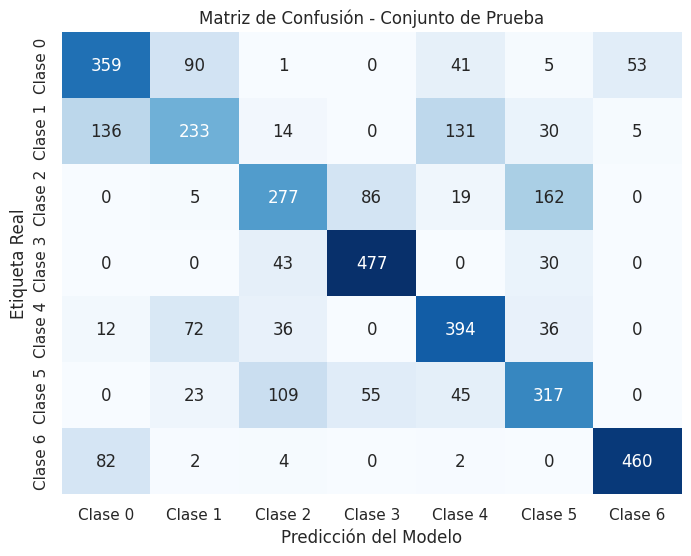

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.61      0.65      0.63       549
           1       0.55      0.42      0.48       549
           2       0.57      0.50      0.54       549
           3       0.77      0.87      0.82       550
           4       0.62      0.72      0.67       550
           5       0.55      0.58      0.56       549
           6       0.89      0.84      0.86       550

    accuracy                           0.65      3846
   macro avg       0.65      0.65      0.65      3846
weighted avg       0.65      0.65      0.65      3846


--- Ejemplo de Predicciones vs Reales ---
Instancia 1: Etiqueta Real = Clase 1, Predicción del Modelo = Clase 2
Instancia 2: Etiqueta Real = Clase 0, Predicción del Modelo = Clase 0
Instancia 3: Etiqueta Real = Clase 5, Predicción del Modelo = Clase 5
Instancia 4: Etiqueta Real = Clase 2, Predicción del Modelo = Clase 5
Instancia 5: Etiqueta Real = Clase 5, Predicción del 

In [22]:
# Predicciones finales
y_pred = clf.predict(X_test_scaled)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f"Clase {i}" for i in range(7)],
            yticklabels=[f"Clase {i}" for i in range(7)])
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred))

# Evidencia de predicciones individuales
print("\n--- Ejemplo de Predicciones vs Reales ---")
for i in range(5):
    print(f"Instancia {i+1}: Etiqueta Real = Clase {y_test.iloc[i]}, Predicción del Modelo = Clase {y_pred[i]}")

# Cuadernillo de Clasificación Multiclase: Parte 2
## Clasificación de Dígitos con MNIST (PyTorch)

### 1. Introducción y Descripción del Dataset
El dataset **MNIST** (Modified National Institute of Standards and Technology) es el conjunto de datos más emblemático en la historia del Machine Learning. Contiene imágenes de dígitos escritos a mano.

**Características principales:**
*   **Instancias totales:** 70,000 imágenes en escala de grises.
*   **Resolución:** 28x28 píxeles por imagen.
*   **Clases (Target):** 10 clases, correspondientes a los dígitos del 0 al 9.
*   **Dimensionalidad:** Al aplanar cada imagen (28x28), obtenemos un vector de 784 características.

In [23]:
# Importar librerías de PyTorch y otras utilidades
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.datasets as datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Descargar MNIST (unimos train y test originales para procesarlos con Pandas)
print("Descargando MNIST...")
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

# Extraer los tensores de imágenes y etiquetas
X_all = torch.cat((mnist_train.data, mnist_test.data), dim=0).float()
y_all = torch.cat((mnist_train.targets, mnist_test.targets), dim=0)

print(f"Total de imágenes descargadas: {X_all.shape[0]}")

Descargando MNIST...
Total de imágenes descargadas: 70000


### 2. Preprocesamiento y Balanceo de Clases con Pandas

Utilizaremos Pandas para gestionar el preprocesamiento de las imágenes antes de introducirlas en el modelo.

**Estrategia:**
1.  **Aplanamiento:** Convertimos las matrices 2D en vectores 1D de 784 píxeles.
2.  **Normalización:** Dividimos entre 255 para escalar los valores al rango [0, 1].
3.  **Balanceo Estricto:** Aplicamos **Submuestreo (Undersampling)** para asegurar que todas las clases tengan la misma representación, evitando sesgos en el entrenamiento.

In [24]:
# Aplanar las imágenes (de 70000x28x28 a 70000x784)
X_flat = X_all.view(X_all.shape[0], -1).numpy()
y_numpy = y_all.numpy()

# Crear DataFrame de Pandas
pixel_cols = [f'pixel_{i}' for i in range(X_flat.shape[1])]
df_mnist = pd.DataFrame(X_flat, columns=pixel_cols)
df_mnist['Target'] = y_numpy

# 1. Normalización usando Pandas (dividir entre 255 para que los valores queden entre 0 y 1)
df_mnist[pixel_cols] = df_mnist[pixel_cols] / 255.0

print("Distribución original de clases en MNIST:")
print(df_mnist['Target'].value_counts().sort_index())

# 2. Balanceo de clases (Undersampling)
min_class_size = df_mnist['Target'].value_counts().min()
print(f"\nLa clase con menos ejemplos tiene {min_class_size} imágenes. Balanceando...")

df_balanced = df_mnist.groupby('Target').apply(lambda x: x.sample(min_class_size, random_state=42)).reset_index(drop=True)

print("\nDistribución después del balanceo:")
print(df_balanced['Target'].value_counts().sort_index())

# Separar Features y Target después de procesar
X_procesado = df_balanced.drop('Target', axis=1).values
y_procesado = df_balanced['Target'].values

Distribución original de clases en MNIST:
Target
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

La clase con menos ejemplos tiene 6313 imágenes. Balanceando...


/tmp/ipykernel_12205/1040865117.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_mnist.groupby('Target').apply(lambda x: x.sample(min_class_size, random_state=42)).reset_index(drop=True)



Distribución después del balanceo:
Target
0    6313
1    6313
2    6313
3    6313
4    6313
5    6313
6    6313
7    6313
8    6313
9    6313
Name: count, dtype: int64


### 3. División de Datos (80% Entrenamiento, 20% Prueba)

Separamos los datos y los transformamos a **Tensores de PyTorch**. Esto nos permite aprovechar el motor de diferenciación automática (*autograd*) para optimizar los parámetros $\theta$ eficientemente mediante el uso de `DataLoaders`.

In [25]:
# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_procesado, y_procesado, test_size=0.20, random_state=42, stratify=y_procesado
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Tamaño de prueba: {X_test.shape[0]} imágenes")

# Convertir a Tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Crear DataLoaders para manejar los datos por lotes (batches)
batch_size = 256
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Tamaño de entrenamiento: 50504 imágenes
Tamaño de prueba: 12626 imágenes


### 4. Implementación del Modelo de Regresión Logística en PyTorch

En PyTorch, la regresión logística multiclase se define mediante una única capa lineal (`nn.Linear`).

**Estimación de parámetros $\theta$:**
*   La capa lineal crea una matriz de pesos que representa nuestros parámetros $\theta$.
*   Utilizaremos `CrossEntropyLoss`, que combina **Softmax** y el cálculo del error logarítmico, ideal para problemas multiclase.

In [26]:
# Definir el modelo
class LogisticRegressionPyTorch(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LogisticRegressionPyTorch, self).__init__()
        # nn.Linear equivale a la ecuación multiclase: x * Theta^T + bias
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

# Instanciar el modelo (784 entradas, 10 clases)
model = LogisticRegressionPyTorch(input_dim=784, num_classes=10)

# Definir la función de Costo y el Optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### 5. Entrenamiento y Validación

El proceso de entrenamiento consiste en iterar sobre el dataset por varias épocas, realizando la propagación hacia adelante (*forward pass*), el cálculo del error y la actualización de los pesos mediante retropropagación (*backpropagation*).

In [27]:
epochs = 20
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

print("Iniciando entrenamiento...")

for epoch in range(epochs):
    # --- ENTRENAMIENTO ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()             # Limpiar gradientes
        outputs = model(inputs)           # Forward pass
        loss = criterion(outputs, labels) # Calcular costo
        loss.backward()                   # Backward pass (calcular derivadas)
        optimizer.step()                  # Actualizar Theta

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- VALIDACIÓN (PRUEBA) ---
    model.eval()
    running_test_loss, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test

    # Almacenar métricas
    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/{epochs}] - Costo Train: {epoch_train_loss:.4f}, Acc Train: {epoch_train_acc:.4f} | Costo Test: {epoch_test_loss:.4f}, Acc Test: {epoch_test_acc:.4f}")

print("Entrenamiento finalizado.")

Iniciando entrenamiento...
Época [1/20] - Costo Train: 0.4072, Acc Train: 0.8841 | Costo Test: 0.3083, Acc Test: 0.9122
Época [5/20] - Costo Train: 0.2659, Acc Train: 0.9251 | Costo Test: 0.2783, Acc Test: 0.9225
Época [10/20] - Costo Train: 0.2544, Acc Train: 0.9282 | Costo Test: 0.2790, Acc Test: 0.9229
Época [15/20] - Costo Train: 0.2473, Acc Train: 0.9300 | Costo Test: 0.2816, Acc Test: 0.9253
Época [20/20] - Costo Train: 0.2466, Acc Train: 0.9304 | Costo Test: 0.2937, Acc Test: 0.9219
Entrenamiento finalizado.


### 6. Gráficas de Costo y Precisión

Visualizaremos la evolución del aprendizaje mediante curvas que muestran cómo disminuye la pérdida (Loss) y cómo aumenta la precisión (Accuracy) en ambos conjuntos de datos.

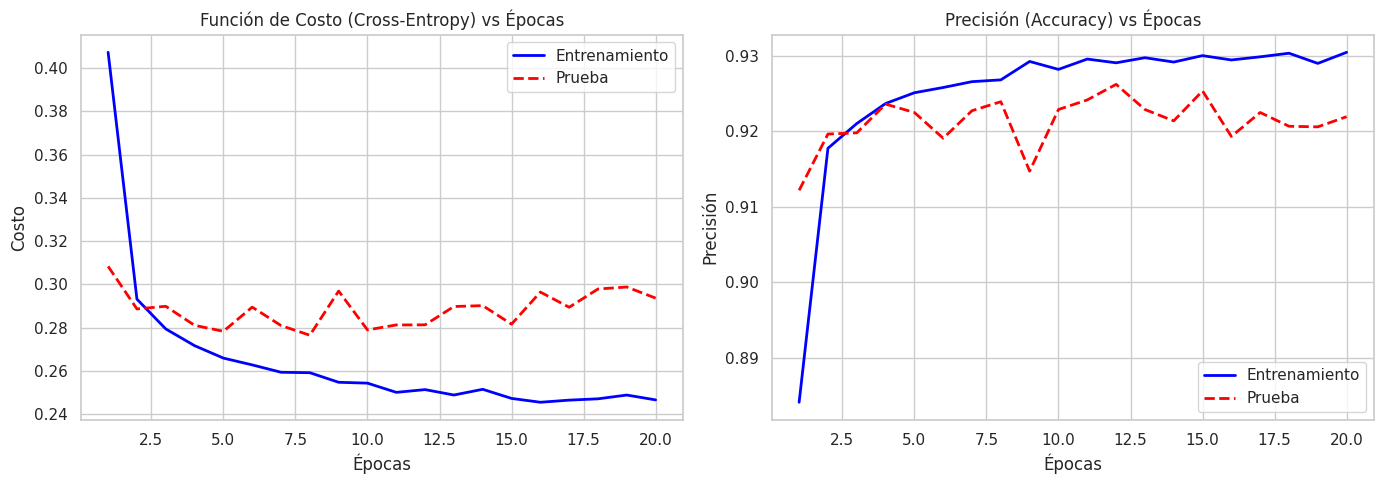

In [28]:
plt.figure(figsize=(14, 5))

# Gráfica de Costo (Loss)
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(1, epochs+1), test_losses, label='Prueba', color='red', linestyle='--', linewidth=2)
plt.title('Función de Costo (Cross-Entropy) vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Costo')
plt.legend()

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(range(1, epochs+1), test_accuracies, label='Prueba', color='red', linestyle='--', linewidth=2)
plt.title('Precisión (Accuracy) vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Generación de Predicciones y Evaluación Visual

Finalizamos el análisis evaluando el modelo con la matriz de confusión y visualizando ejemplos aleatorios del conjunto de prueba para comparar la etiqueta real con la predicción del modelo.

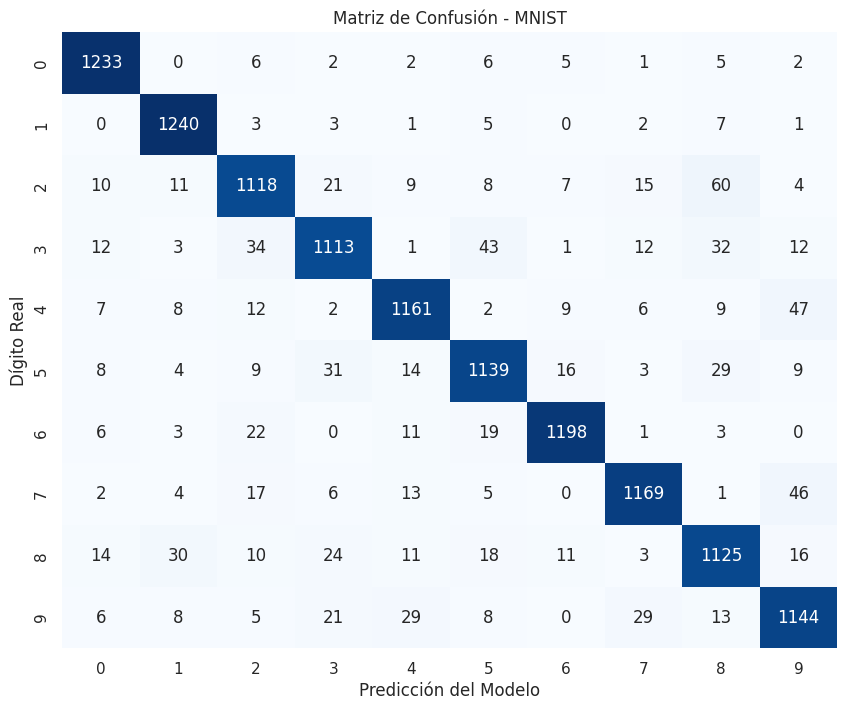

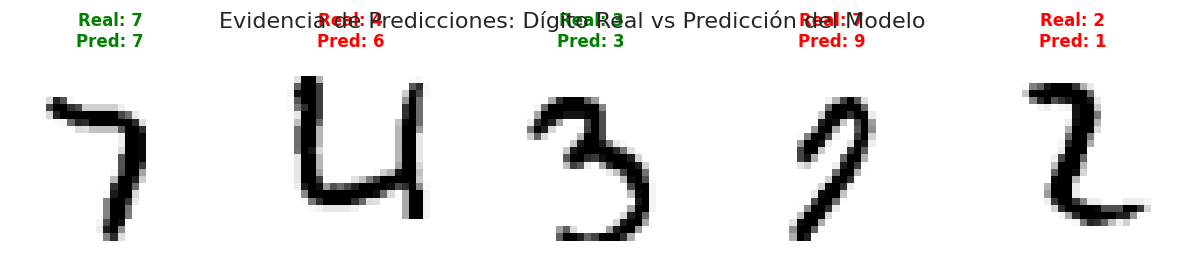

In [29]:
# Obtener predicciones finales para todo el set de prueba
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# 1. Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - MNIST')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Dígito Real')
plt.show()

# 2. Visualización de predicciones individuales
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Evidencia de Predicciones: Dígito Real vs Predicción del Modelo', fontsize=16)

for i in range(5):
    idx = np.random.randint(0, len(X_test_t))
    img = X_test_t[idx].view(28, 28).numpy()
    real_label = y_test_t[idx].item()
    pred_label = all_preds[idx]

    axes[i].imshow(img, cmap='gray_r')
    axes[i].set_title(f"Real: {real_label}\nPred: {pred_label}",
                      color="green" if real_label == pred_label else "red", fontweight='bold')
    axes[i].axis('off')

plt.show()